# Part 25: Factor Exposures and Risk Adjustment


A selected feature or signal may still be difficult to interpret if it is largely a disguised exposure to common risk factors.
For that reason, it is often useful to ask how much of a signal's behavior is explained by broad factor movements and how much remains after risk adjustment.

In this Part we use a simple rolling factor model to illustrate two ideas.

1. Estimating factor exposures.
2. Constructing a residual, or risk-adjusted, version of a signal.


**Exercise.** Why might a long-short strategy with strong raw returns still be disappointing if most of its performance comes from broad market exposure?


<div class="lecture-pagebreak"></div>

## Basic Terms

We use the following terms in this Part.

A **factor exposure** is the sensitivity of an asset or strategy to a common source of variation.
A **beta** is a regression coefficient measuring this sensitivity.
**Alpha** is the component of return not explained by the factor specification being used.
A **residual return** is the realized return minus the fitted value from a factor model.
A **risk-adjusted signal** is a signal formed after removing some common factor component.

None of these quantities is model-free.
They depend on the chosen factor set and estimation window.


**Exercise.** Explain why the same stock can have different estimated factor exposures under different factor specifications.


<div class="lecture-pagebreak"></div>

## Why Risk Adjustment Matters

Risk adjustment is useful for at least three reasons.

1. It helps distinguish common factor exposure from asset-specific information.
2. It provides a cleaner basis for comparing raw and residual signals.
3. It helps explain why a strategy behaves as it does during broad market moves.

In practice one rarely removes all systematic variation.
The point is to understand what the signal is loading on and whether those exposures are desired.


## Example Setup

We use the same small equity universe as in Part 24.
As simple factor proxies we use exchange-traded funds:

1. `SPY` for the broad market.
2. `IWM - SPY` as a size spread proxy.
3. `IWD - IWF` as a value-versus-growth proxy.

These are only rough proxies, but they are sufficient for an instructional example.


<div class="lecture-pagebreak"></div>

## Rolling Exposures and Residual Returns

We estimate rolling factor exposures with a 24-month window.
This produces two objects.

1. Estimated exposures through time.
2. Residual returns after removing the fitted factor component.

We then compare a raw momentum signal to a momentum signal built from residual returns.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lecture_utils import download_adjusted_close_panel
from backtest_utils import build_equal_weight_long_short, fit_factor_model, portfolio_summary, rolling_factor_regression


In [2]:
UNIVERSE = ['AAPL', 'MSFT', 'AMZN', 'GOOG', 'META', 'NVDA', 'JPM', 'XOM', 'JNJ', 'UNH', 'PG', 'HD']
FACTOR_ETFS = ['SPY', 'IWM', 'IWD', 'IWF']
START = '2014-01-01'
END = '2026-03-01'

asset_prices = download_adjusted_close_panel(UNIVERSE, START, END)
factor_prices = download_adjusted_close_panel(FACTOR_ETFS, START, END)

asset_monthly = asset_prices.resample('ME').last().pct_change()
factor_monthly_raw = factor_prices.resample('ME').last().pct_change()

factor_returns = pd.DataFrame({
    'market': factor_monthly_raw['SPY'],
    'size': factor_monthly_raw['IWM'] - factor_monthly_raw['SPY'],
    'value': factor_monthly_raw['IWD'] - factor_monthly_raw['IWF'],
}).dropna()

asset_monthly.tail()


,AAPL,AMZN,GOOG,HD,JNJ,JPM,META,MSFT,NVDA,PG,UNH,XOM
Date,,,,,,,,,,,,
2025-10-31,0.061815,0.112265,0.157134,-0.063180,0.018606,-0.008869,-0.117146,-0.000270,0.085272,-0.014504,-0.010831,0.014279
2025-11-30,0.032364,-0.045041,0.135902,-0.059722,0.102524,0.006300,-0.000617,-0.048047,-0.125883,-0.014697,-0.034518,0.022507
2025-12-31,-0.025067,-0.010291,-0.019103,-0.029683,0.000145,0.029194,0.019567,-0.017053,0.053731,-0.032735,0.007761,0.038130
2026-01-31,-0.045538,0.036739,0.078808,0.088608,0.098091,-0.046397,0.085458,-0.110273,0.024826,0.066552,-0.130805,0.175004
2026-02-28,0.019066,-0.122440,-0.080052,0.016365,0.099013,-0.018275,-0.095352,-0.085183,-0.072935,0.101667,0.022096,0.085689


In [3]:
residuals, exposures = rolling_factor_regression(asset_monthly, factor_returns, window=24)

latest_exposure_snapshot = pd.DataFrame({
    factor: exposures[factor].iloc[-1] for factor in ['market', 'size', 'value']
})
latest_exposure_snapshot.head()


,market,size,value
AAPL,0.144542,0.549217,-0.613761
AMZN,1.061621,0.351112,-0.789641
GOOG,-0.140959,0.740911,-1.050968
HD,1.241544,0.665550,0.224401
JNJ,0.782229,-0.193749,0.949044


The table above reports the most recent estimated factor exposures from the rolling model.
These are descriptive estimates, not structural quantities.
They depend on the chosen proxies and estimation window.


In [4]:
raw_signal = asset_monthly.shift(1).rolling(6).sum()
residual_signal = residuals.shift(1).rolling(6).sum()
future_returns = asset_monthly.shift(-1)

raw_weights, raw_portfolio, raw_turnover = build_equal_weight_long_short(raw_signal, future_returns, top_n=3, bottom_n=3)
resid_weights, resid_portfolio, resid_turnover = build_equal_weight_long_short(residual_signal, future_returns, top_n=3, bottom_n=3)

comparison = pd.concat([
    portfolio_summary(raw_portfolio, raw_turnover, periods_per_year=12).assign(strategy='raw_momentum'),
    portfolio_summary(resid_portfolio, resid_turnover, periods_per_year=12).assign(strategy='residual_momentum'),
], ignore_index=True)
comparison[['strategy', 'annualized_return', 'annualized_volatility', 'sharpe_like_ratio', 'hit_rate', 'average_turnover']]


,strategy,annualized_return,annualized_volatility,sharpe_like_ratio,hit_rate,average_turnover
0,raw_momentum,0.152514,0.226147,0.674400,0.582192,0.547945
1,residual_momentum,-0.018633,0.176198,-0.105752,0.413793,0.462069


### Factor Model Comparison

We now fit the same proxy factor model to the two long-short portfolios.
This is a simple way to compare the raw signal to the risk-adjusted signal.


In [5]:
raw_fit = fit_factor_model(raw_portfolio, factor_returns)
resid_fit = fit_factor_model(resid_portfolio, factor_returns)

factor_summary = pd.DataFrame([
    {
        'strategy': 'raw_momentum',
        'alpha_annualized': 12 * raw_fit['alpha'],
        'market_beta': raw_fit['betas']['market'],
        'size_beta': raw_fit['betas']['size'],
        'value_beta': raw_fit['betas']['value'],
        'r2': raw_fit['r2'],
    },
    {
        'strategy': 'residual_momentum',
        'alpha_annualized': 12 * resid_fit['alpha'],
        'market_beta': resid_fit['betas']['market'],
        'size_beta': resid_fit['betas']['size'],
        'value_beta': resid_fit['betas']['value'],
        'r2': resid_fit['r2'],
    },
])
factor_summary


,strategy,alpha_annualized,market_beta,size_beta,value_beta,r2
0,raw_momentum,0.130118,0.129183,-0.040012,-0.071679,0.009039
1,residual_momentum,-0.016933,-0.073889,0.013313,-0.165014,0.010616


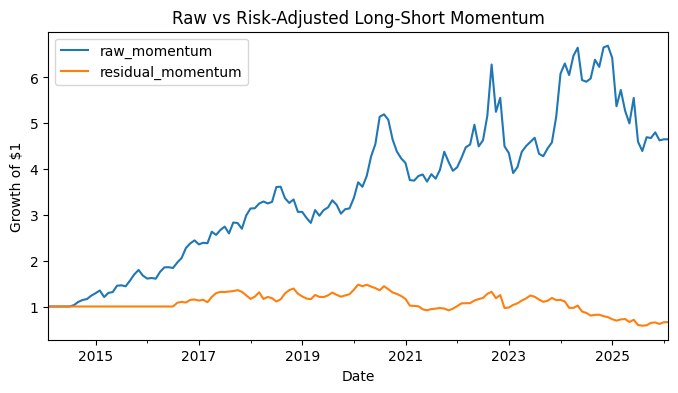

In [6]:
cumulative = pd.DataFrame({
    'raw_momentum': (1 + raw_portfolio).cumprod(),
    'residual_momentum': (1 + resid_portfolio).cumprod(),
}).dropna()

ax = cumulative.plot(figsize=(8, 4), title='Raw vs Risk-Adjusted Long-Short Momentum')
ax.set_ylabel('Growth of $1')
plt.show()


**Exercise.** If the residual signal has lower market beta but also lower return, what additional information would you want before deciding which version is preferable?


<div class="lecture-pagebreak"></div>

## Interpreting the Comparison

If the residual portfolio has smaller factor loadings than the raw portfolio, then the adjustment has succeeded in reducing common-factor exposure under the chosen model.
This does not imply that the residual portfolio is superior.
It may have lower return, higher turnover, or less stable behavior.

The main purpose of the exercise is diagnostic.
It helps answer the question: is the signal primarily a repackaged factor bet, or does it retain some distinct component after adjustment?


## Exercises

**Exercise 1.** Change the rolling estimation window from 24 months to 36 months. How do the exposure estimates change?

**Exercise 2.** Replace the factor proxies with a different set of ETFs. Which results are most sensitive to this change?

**Exercise 3.** Why is it useful to compare the factor exposures of the portfolio, rather than only the factor exposures of the individual stocks?

**Exercise 4.** Give an example of a signal that might be attractive precisely because it carries a known factor exposure rather than despite it.


## References

1. Fama and French (1993), *Common Risk Factors in the Returns on Stocks and Bonds*.
2. Grinold and Kahn, *Active Portfolio Management*.
3. Cochrane, *Asset Pricing*.
4. Lopez de Prado (2018), *Advances in Financial Machine Learning*.
